In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
connection = sqlite3.connect('Chinook_Sqlite.sqlite')
cursor = connection.cursor()

In [5]:
cursor.execute("SELECT sqlite_version()")
print(cursor.fetchone())

('3.50.4',)


In [33]:
#Listing all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()

for table in tables:
    print(table)

('Album',)
('Artist',)
('Customer',)
('Employee',)
('Genre',)
('Invoice',)
('InvoiceLine',)
('MediaType',)
('Playlist',)
('PlaylistTrack',)
('Track',)


In [39]:
#Inspecting each table's structure
for table in tables:
    print(table[0])
    cursor.execute(f"PRAGMA table_info({table[0]})")
    print(cursor.fetchall())

Album
[(0, 'AlbumId', 'INTEGER', 1, None, 1), (1, 'Title', 'NVARCHAR(160)', 1, None, 0), (2, 'ArtistId', 'INTEGER', 1, None, 0)]
Artist
[(0, 'ArtistId', 'INTEGER', 1, None, 1), (1, 'Name', 'NVARCHAR(120)', 0, None, 0)]
Customer
[(0, 'CustomerId', 'INTEGER', 1, None, 1), (1, 'FirstName', 'NVARCHAR(40)', 1, None, 0), (2, 'LastName', 'NVARCHAR(20)', 1, None, 0), (3, 'Company', 'NVARCHAR(80)', 0, None, 0), (4, 'Address', 'NVARCHAR(70)', 0, None, 0), (5, 'City', 'NVARCHAR(40)', 0, None, 0), (6, 'State', 'NVARCHAR(40)', 0, None, 0), (7, 'Country', 'NVARCHAR(40)', 0, None, 0), (8, 'PostalCode', 'NVARCHAR(10)', 0, None, 0), (9, 'Phone', 'NVARCHAR(24)', 0, None, 0), (10, 'Fax', 'NVARCHAR(24)', 0, None, 0), (11, 'Email', 'NVARCHAR(60)', 1, None, 0), (12, 'SupportRepId', 'INTEGER', 0, None, 0)]
Employee
[(0, 'EmployeeId', 'INTEGER', 1, None, 1), (1, 'LastName', 'NVARCHAR(20)', 1, None, 0), (2, 'FirstName', 'NVARCHAR(20)', 1, None, 0), (3, 'Title', 'NVARCHAR(30)', 0, None, 0), (4, 'ReportsTo', 'IN

In [76]:
#Which are the 10 best-selling tracks?
cursor.execute("""
    SELECT Track.Name, SUM(InvoiceLine.Quantity) AS total_quantity
    FROM InvoiceLine 
    JOIN Track ON InvoiceLine.TrackId = Track.TrackId 
    GROUP BY Track.Name 
    ORDER BY total_quantity DESC 
    LIMIT 10;"""
)

top10_tracks = cursor.fetchall()

for track in top10_tracks:
    print(track)

('The Trooper', 5)
('Untitled', 4)
('The Number Of The Beast', 4)
('Sure Know Something', 4)
('Hallowed Be Thy Name', 4)
('Eruption', 4)
('Where Eagles Dare', 3)
('Welcome Home (Sanitarium)', 3)
('Sweetest Thing', 3)
('Surrender', 3)


In [50]:
#Which country generates the most revenue?
cursor.execute("""
    SELECT BillingCountry, SUM(Invoice.Total) AS total_revenue
    FROM Invoice
    GROUP BY BillingCountry
    ORDER BY total_revenue DESC
    LIMIT 1;
""")

print(cursor.fetchall())

[('USA', 523.06)]


In [56]:
#Who is the top-performing sales employee?
cursor.execute("""
    SELECT Employee.FirstName ||' '|| Employee.LastName AS employee_name, SUM(Invoice.Total) AS employee_sales
    FROM Employee
    JOIN Customer ON Employee.EmployeeId = Customer.SupportRepId
    JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
    GROUP BY Employee.FirstName, Employee.LastName
    ORDER BY employee_sales DESC
    LIMIT 1;
""")

print(cursor.fetchall())

[('Jane Peacock', 833.04)]


In [60]:
# Which top 10 artists have more than 10 tracks in the store?
cursor.execute("""
    SELECT Artist.Name, COUNT(Track.TrackId) AS total_tracks
    FROM Artist
    JOIN Album ON Artist.ArtistId = Album.ArtistId
    JOIN Track ON Album.AlbumId = Track.AlbumId
    GROUP BY Artist.Name
    HAVING COUNT(Track.TrackId) > 10
    ORDER BY total_tracks DESC
    LIMIT 10;
""")

top10_artists = cursor.fetchall()

for artist in top10_artists:
    print(artist)

('Iron Maiden', 213)
('U2', 135)
('Led Zeppelin', 114)
('Metallica', 112)
('Lost', 92)
('Deep Purple', 92)
('Pearl Jam', 67)
('Lenny Kravitz', 57)
('Various Artists', 56)
('The Office', 53)


In [61]:
# Which tracks have never been sold?
cursor.execute("""
    SELECT Track.Name
    FROM Track
    LEFT JOIN InvoiceLine ON Track.TrackId = InvoiceLine.TrackId
    WHERE InvoiceLine.TrackId IS NULL
""")

print(cursor.fetchall())

[("Let's Get It Up",), ('C.O.D.',), ('Let There Be Rock',), ('Bad Boy Boogie',), ('Whole Lotta Rosie',), ('Walk On Water',), ('Dude (Looks Like A Lady)',), ("Cryin'",), ('The Other Side',), ('Crazy',), ('Eat The Rich',), ('Perfect',), ('Hand In My Pocket',), ('Head Over Feet',), ('Mary Jane',), ('Ironic',), ('You Oughta Know (Alternate)',), ('We Die Young',), ('Man In The Box',), ('Love, Hate, Love',), ('Sunshine',), ('Put You Down',), ('Desafinado',), ('Garota De Ipanema',), ('Samba De Uma Nota Só (One Note Samba)',), ('Fotografia',), ('Dindi (Dindi)',), ('Se Todos Fossem Iguais A Você (Instrumental)',), ('Corcovado (Quiet Nights Of Quiet Stars)',), ('Outra Vez',), ('Enter Sandman',), ('Harvester Of Sorrow',), ('Sad But True',), ('Creeping Death',), ('Wherever I May Roam',), ('Show Me How to Live',), ('Gasoline',), ('What You Are',), ('Shadow on the Sun',), ('I am the Highway',), ("Bring'em Back Alive",), ('Light My Way',), ('Getaway Car',), ('Out Of Exile',), ('Be Yourself',), ("Heav

In [ ]:
# Loading queries into Pandas dataframes
# (Queries have been updated to optimize for viz)

query1 = """ 
    SELECT Track.Name, SUM(InvoiceLine.Quantity) AS total_quantity
    FROM InvoiceLine 
    JOIN Track ON InvoiceLine.TrackId = Track.TrackId 
    GROUP BY Track.Name 
    ORDER BY total_quantity DESC 
    LIMIT 10;"""

top10_tracks_df = pd.read_sql(query1, connection)
#print(top10_tracks_df.head())


query2 = """
    SELECT BillingCountry, SUM(Invoice.Total) AS total_revenue
    FROM Invoice
    GROUP BY BillingCountry
    ORDER BY total_revenue DESC
    LIMIT 10;"""

country_revenue_df = pd.read_sql(query2, connection)
#print(country_revenue_df.head())


query3 = """
    SELECT Employee.FirstName ||' '|| Employee.LastName AS employee_name, SUM(Invoice.Total) AS employee_sales
    FROM Employee
    JOIN Customer ON Employee.EmployeeId = Customer.SupportRepId
    JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
    GROUP BY Employee.FirstName, Employee.LastName
    ORDER BY employee_sales DESC;"""

top_sales_employee_df = pd.read_sql(query3, connection)
#print(top_sales_employee_df.head())


query4 = """
    SELECT Artist.Name, COUNT(Track.TrackId) AS total_tracks
    FROM Artist
    JOIN Album ON Artist.ArtistId = Album.ArtistId
    JOIN Track ON Album.AlbumId = Track.AlbumId
    GROUP BY Artist.Name
    HAVING COUNT(Track.TrackId) > 10
    ORDER BY total_tracks DESC
    LIMIT 10;"""

top10_artists_df = pd.read_sql(query4, connection)
#print(top10_artists_df.head())


query5 = """
    SELECT Track.Name
    FROM Track
    LEFT JOIN InvoiceLine ON Track.TrackId = InvoiceLine.TrackId
    WHERE InvoiceLine.TrackId IS NULL"""

tracks_not_sold_df = pd.read_sql(query5, connection)
#print(tracks_not_sold_df.head())

           Name  total_tracks
0   Iron Maiden           213
1            U2           135
2  Led Zeppelin           114
3     Metallica           112
4          Lost            92


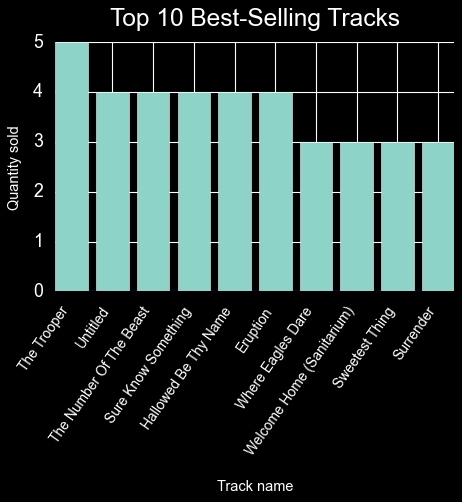

In [180]:
# Visuailzing data using matplotlib

#Q1
plt.style.use('dark_background')
plt.figure(figsize=(6,6.5))
plt.bar(top10_tracks_df['Name'], top10_tracks_df['total_quantity'])
plt.title('Top 10 Best-Selling Tracks', pad=15, fontsize=22)
plt.xlabel('Track name', labelpad=20, fontsize=13)
plt.ylabel('Quantity sold', labelpad=10, fontsize=13)
plt.xticks(rotation=55, ha='right', fontsize = 12.5)
plt.tight_layout()


plt.show()

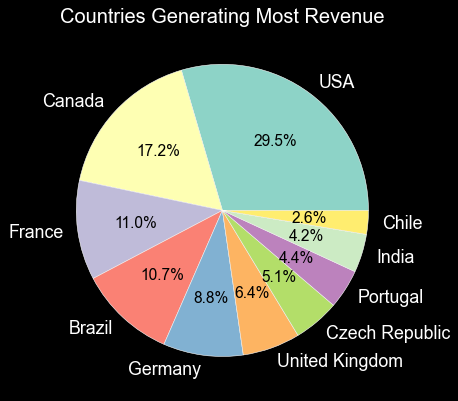

In [195]:
#Q2
plt.style.use('dark_background')
plt.figure(figsize=(7,5.5))
wedges, labels, pcts = plt.pie(country_revenue_df['total_revenue'], labels=country_revenue_df['BillingCountry'], autopct='%1.1f%%')
plt.title('Countries Generating Most Revenue', fontsize = 18)

for pct in pcts:
    pct.set_color('black')

plt.show()

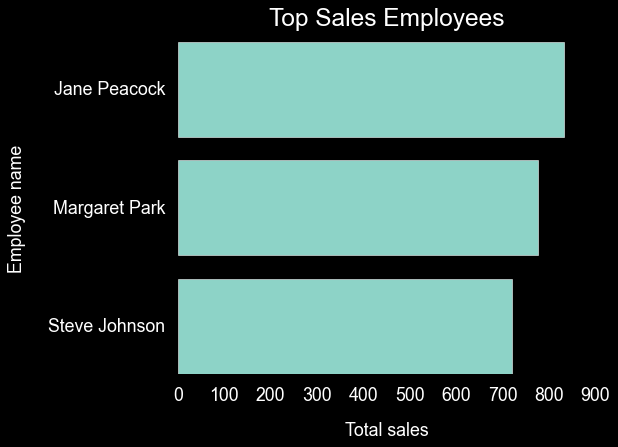

In [219]:
#Q3
plt.style.use('dark_background')
plt.figure(figsize=(6,5))
top_sales_employee_df = top_sales_employee_df.sort_values('employee_sales', ascending=True)
plt.barh(top_sales_employee_df['employee_name'], top_sales_employee_df['employee_sales'])
plt.title('Top Sales Employees', pad=15, fontsize=22)
plt.xlabel('Total sales', labelpad=15, fontsize=16)
plt.ylabel('Employee name', labelpad=20, fontsize=16)
plt.grid(False)


plt.show()

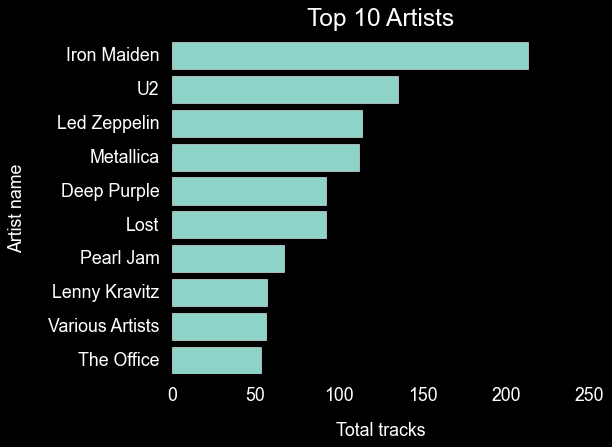

In [217]:
#Q4
plt.style.use('dark_background')
plt.figure(figsize=(6,5))
top10_artists_df = top10_artists_df.sort_values('total_tracks', ascending=True)
plt.barh(top10_artists_df['Name'], top10_artists_df['total_tracks'])
plt.title('Top 10 Artists', pad=15, fontsize=22)
plt.xlabel('Total tracks', labelpad=15, fontsize=16)
plt.ylabel('Artist name', labelpad=20, fontsize=16)
plt.grid(False)


plt.show()